# Palm Fruit Ripeness Classification (Refined)


This notebook trains and evaluates a palm fruit ripeness classifier with **MobileNetV2** transfer learning. The workflow emphasises correct data splits, proper preprocessing, and reproducible training/evaluation steps.



### What’s improved versus the baseline
1. **Clean splits:** Training data is split into train/validation; the test set stays completely held out to avoid leakage.
2. **Correct preprocessing:** Uses `preprocess_input` for MobileNetV2 so pixels match the expected [-1, 1] range.
3. **Stronger regularisation:** In-model data augmentation reduces overfitting.
4. **Optional fine-tuning:** Unfreezes top layers after the backbone is warmed up to recover extra accuracy.
5. **Aligned evaluation:** Predictions and labels come from the same pipeline to prevent mismatches.
6. **Cross-platform paths:** TensorFlow string ops normalise separators on Windows.
7. **Timestamped artifacts:** Saved models, plots, and reports avoid accidental overwrites.



## 1. Imports & Configuration


Edit paths, image size, batch size, seeds, and run flags here before executing the rest of the notebook.

In [ ]:
import os
import datetime
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras import utils
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix

# ---------- User config (edit as needed) ----------
DATASET_ROOT = os.getenv("DATASET_ROOT", r"C:\\Users\\jeffy\\Documents\\PSM\\Dataset1")
TRAIN_ROOT = os.getenv("TRAIN_ROOT", os.path.join(DATASET_ROOT, "Train"))
TEST_ROOT = os.getenv("TEST_ROOT", os.path.join(DATASET_ROOT, "Test"))

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
AUTOTUNE    = tf.data.AUTOTUNE
SEED        = 42
VAL_SPLIT   = 0.2          # 20% of training data reserved for validation (prevents data leakage)

# Run modes
DO_TRAIN          = True   # Set True to run full training
DO_SMOKE          = False    # Run a short 1-epoch smoke test to validate the pipeline
DO_FINE_TUNE      = True   # Set True to fine-tune top layers of MobileNetV2 after initial training
SMOKE_TRAIN_STEPS = 100     # Number of batches for the smoke test
SMOKE_VAL_STEPS   = 20
EPOCHS            = 30      # Full training epochs
FINE_TUNE_EPOCHS  = 15       # Extra epochs for the fine-tuning phase

# Output directory for saved models (timestamped to avoid overwrites)
MODEL_DIR = "saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)
TIMESTAMP = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU available: []


## 2. Load & Split Datasets


The training directory is split into **80% train / 20% validation** via `validation_split`. The test directory is loaded only for final evaluation, so callbacks never see test data.

Included safeguards:
- Filesystem counts per class are printed to catch empty folders early.
- A missing or empty training set raises a clear error.
- Detected class names are stored for later evaluation and plotting.

In [13]:
# ---------- Helper: count files in a directory tree ----------
def count_images(root):
    """Count image files per class folder. Returns (dict of counts, total)."""
    counts = {}
    total = 0
    if not os.path.exists(root):
        return counts, total
    for cls in sorted(os.listdir(root)):
        p = os.path.join(root, cls)
        if os.path.isdir(p):
            files = [f for f in os.listdir(p) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            counts[cls] = len(files)
            total += len(files)
    return counts, total

train_counts, train_total = count_images(TRAIN_ROOT)
test_counts, test_total = count_images(TEST_ROOT)
print("Filesystem counts:")
print("  Train:", train_counts, "=>", train_total)
print("  Test :", test_counts, "=>", test_total)

if train_total == 0:
    raise FileNotFoundError(f"No training images found under {TRAIN_ROOT}")

# ---------- Create tf.data datasets with proper train/val split ----------
# FIX #1: Split training data into train + validation subsets.
# The test set is NEVER used during training — only for final evaluation.
train_ds = utils.image_dataset_from_directory(
    TRAIN_ROOT,
    labels="inferred",
    label_mode="categorical",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset="training",
)

val_ds = utils.image_dataset_from_directory(
    TRAIN_ROOT,
    labels="inferred",
    label_mode="categorical",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset="validation",
)

# Test set — loaded only for final evaluation (never seen during training)
test_ds = None
if test_total > 0:
    test_ds = utils.image_dataset_from_directory(
        TEST_ROOT,
        labels="inferred",
        label_mode="categorical",
        batch_size=BATCH_SIZE,
        image_size=IMG_SIZE,
        shuffle=False,
    )

class_names = train_ds.class_names
num_classes = len(class_names)
print("Detected classes:", class_names)
print(f"Num classes: {num_classes}")

Filesystem counts:
  Train: {'Overripe': 400, 'Ripe': 400, 'Underripe': 400} => 1200
  Test : {'Overripe': 60, 'Ripe': 60, 'Underripe': 60} => 180
Found 1200 files belonging to 3 classes.
Using 960 files for training.
Found 1200 files belonging to 3 classes.
Using 240 files for validation.
Found 180 files belonging to 3 classes.
Detected classes: ['Overripe', 'Ripe', 'Underripe']
Num classes: 3


## 3. Preprocessing


Images are cast to float and passed through MobileNetV2’s `preprocess_input`, which scales pixels to the expected [-1, 1] range. Each dataset is mapped once, then prefetched to keep the GPU fed without redundant prefetch calls.

In [14]:
# ---------- Preprocessing ----------
# FIX #3: Use MobileNetV2's own preprocess_input instead of manual /255.
# MobileNetV2 expects pixels in [-1, 1], not [0, 1].
def preprocess(x, y):
    return preprocess_input(tf.cast(x, tf.float32)), y

# FIX #2: Only one .prefetch() call per dataset (no double prefetch).
train_ds_pp = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds_pp   = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

test_ds_pp = None
if test_ds is not None:
    test_ds_pp = test_ds.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print("Preprocessing applied (MobileNetV2 preprocess_input -> [-1, 1] range)")

Preprocessing applied (MobileNetV2 preprocess_input -> [-1, 1] range)


## 4. Build Model


A data-augmentation block (flip/rotation/zoom) runs only during training. MobileNetV2 (ImageNet weights) is used as a frozen feature extractor; a lightweight head (GAP → dropout → dense → batch norm → dropout → softmax) performs classification. If transfer learning is disabled, a compact CNN fallback is provided.

In [15]:
# ---------- Build model (MobileNetV2 backbone with data augmentation) ----------

# FIX #4: Data augmentation layers — only active during training.
# Helps the model generalise by seeing randomly transformed versions of each image.
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
], name="data_augmentation")

# Load MobileNetV2 as the feature extractor
use_transfer = True
if use_transfer:
    try:
        base_model = tf.keras.applications.MobileNetV2(
            input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet"
        )
        print("Loaded MobileNetV2 with ImageNet weights")
    except Exception as e:
        print("Could not load ImageNet weights (falling back to random init):", e)
        base_model = tf.keras.applications.MobileNetV2(
            input_shape=IMG_SIZE + (3,), include_top=False, weights=None
        )
        print("Loaded MobileNetV2 with random initialization")

    # Freeze all backbone layers for the initial training phase
    base_model.trainable = False

    # Build the full model with augmentation -> backbone -> classifier head
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)          # augmentation (active only during training)
    x = base_model(x, training=False)      # frozen backbone
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = Model(inputs, outputs)
else:
    # Fallback: simple CNN from scratch (no transfer learning)
    model = keras.Sequential([
        layers.Input(shape=IMG_SIZE + (3,)),
        data_augmentation,
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.BatchNormalization(), layers.MaxPooling2D(), layers.Dropout(0.25),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.BatchNormalization(), layers.MaxPooling2D(), layers.Dropout(0.25),
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.BatchNormalization(), layers.MaxPooling2D(), layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()
print(f"\nTotal params: {model.count_params():,}")

Loaded MobileNetV2 with ImageNet weights


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,851 (9.24 MB)

 Trainable params: 164,611 (643.01 KB)

 Non-trainable params: 2,258,240 (8.61 MB)


Total params: 2,422,851


## 5. Callbacks & Training


Training uses EarlyStopping and ReduceLROnPlateau keyed to validation loss when available. Checkpoints are timestamped to avoid overwriting past runs. Optional smoke mode runs a short sanity check; full training runs the frozen backbone stage; an optional fine-tuning stage unfreezes the top 30 backbone layers at a lower learning rate.

In [16]:
# ---------- Callbacks ----------
# FIX #5: Use val_loss when validation data is available, fall back to loss otherwise.
# FIX #8: Save models with timestamps to avoid overwriting previous runs.
monitor_metric = "val_loss" if val_ds_pp is not None else "loss"
best_model_path = os.path.join(MODEL_DIR, f"palm_ripeness_best_{TIMESTAMP}.h5")
final_model_path = os.path.join(MODEL_DIR, f"palm_ripeness_final_{TIMESTAMP}.h5")

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor=monitor_metric, patience=7, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor=monitor_metric, factor=0.5, patience=4, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        best_model_path, monitor=monitor_metric, save_best_only=True
    ),
]

# ---------- Smoke Test ----------
if DO_SMOKE:
    print("\n--- Smoke test (1 epoch) to validate the pipeline ---")
    smoke_train = train_ds_pp.take(SMOKE_TRAIN_STEPS)
    smoke_val = val_ds_pp.take(SMOKE_VAL_STEPS) if val_ds_pp is not None else None
    history = model.fit(
        smoke_train, epochs=1, validation_data=smoke_val, callbacks=callbacks, verbose=1
    )
    print("Smoke test done. Metrics:", {k: round(v[-1], 4) for k, v in history.history.items()})

# ---------- Full Training ----------
if DO_TRAIN:
    print("\n--- Full training (frozen backbone) ---")
    history = model.fit(
        train_ds_pp,
        epochs=EPOCHS,
        validation_data=val_ds_pp,  # FIX #1: Uses validation split, NOT test set
        callbacks=callbacks,
        verbose=1,
    )
    model.save(final_model_path)
    print(f"Saved initial model to {final_model_path}")

# ---------- Fine-Tuning Phase ----------
# FIX #10: Unfreeze the top layers of MobileNetV2 and train at a lower learning rate.
# This lets the pre-trained features adapt slightly to our specific dataset.
if DO_FINE_TUNE and use_transfer and DO_TRAIN:
    print("\n--- Fine-tuning: unfreezing top 30 layers of MobileNetV2 ---")
    base_model.trainable = True
    # Freeze all layers except the last 30
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    # Recompile with a much lower learning rate to avoid destroying pre-trained weights
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    ft_model_path = os.path.join(MODEL_DIR, f"palm_ripeness_finetuned_{TIMESTAMP}.h5")
    ft_callbacks = [
        keras.callbacks.EarlyStopping(
            monitor=monitor_metric, patience=5, restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor=monitor_metric, factor=0.5, patience=3, min_lr=1e-7, verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            ft_model_path, monitor=monitor_metric, save_best_only=True
        ),
    ]

    model.fit(
        train_ds_pp,
        epochs=FINE_TUNE_EPOCHS,
        validation_data=val_ds_pp,
        callbacks=ft_callbacks,
        verbose=1,
    )
    model.save(ft_model_path)
    print(f"Saved fine-tuned model to {ft_model_path}")
elif DO_FINE_TUNE and not DO_TRAIN:
    print("Skipping fine-tuning: DO_TRAIN must be True first.")


--- Full training (frozen backbone) ---
Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.4406 - loss: 1.3752

30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 263ms/step - accuracy: 0.4760 - loss: 1.2984 - val_accuracy: 0.5625 - val_loss: 0.9723 - learning_rate: 1.0000e-04
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.5959 - loss: 0.9920

30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 264ms/step - accuracy: 0.6031 - loss: 0.9502 - val_accuracy: 0.6333 - val_loss: 0.8032 - learning_rate: 1.0000e-04
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.6485 - loss: 0.8160

30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 243ms/step - accuracy: 0.6635 - loss: 0.8019 - val_accuracy: 0.6875 - val_loss: 0.7143 - learning_rate: 1.0000e-04
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.6887 - loss: 0.6990

30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 243ms/step - accuracy: 0.6969 - loss: 0.6877 - val_accuracy: 0.7250 - val_loss: 0.6263 - learning_rate: 1.0000e-04
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.7004 - loss: 0.7046

...

30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 216ms/step - accuracy: 0.8490 - loss: 0.3878 - val_accuracy: 0.8792 - val_loss: 0.3521 - learning_rate: 1.0000e-04
Epoch 22/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 210ms/step - accuracy: 0.8365 - loss: 0.3765 - val_accuracy: 0.8875 - val_loss: 0.3591 - learning_rate: 1.0000e-04
Epoch 23/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8546 - loss: 0.3739

30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 212ms/step - accuracy: 0.8615 - loss: 0.3578 - val_accuracy: 0.8917 - val_loss: 0.3503 - learning_rate: 1.0000e-04
Epoch 24/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 207ms/step - accuracy: 0.8271 - loss: 0.3895 - val_accuracy: 0.8750 - val_loss: 0.3536 - learning_rate: 1.0000e-04
Epoch 25/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 205ms/step - accuracy: 0.8542 - loss: 0.3568 - val_accuracy: 0.8667 - val_loss: 0.3604 - learning_rate: 1.0000e-04
Epoch 26/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 207ms/step - accuracy: 0.8646 - loss: 0.3418 - val_accuracy: 0.8667 - val_loss: 0.3647 - learning_rate: 1.0000e-04
Epoch 27/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8514 - loss: 0.3432
Epoch 27: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 206ms/step - accuracy: 0.8604 - loss: 0.3419 - val_accuracy: 0.8625 - val_loss: 0.3629 - learning_rate: 1.0000e-04
Epoch 28/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 208ms/step - accuracy: 0.8615 - l

Saved initial model to saved_models\palm_ripeness_final_20260311_190835.h5

--- Fine-tuning: unfreezing top 30 layers of MobileNetV2 ---
Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.8225 - loss: 0.4797

30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 290ms/step - accuracy: 0.8062 - loss: 0.4875 - val_accuracy: 0.8583 - val_loss: 0.3724 - learning_rate: 1.0000e-05
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 252ms/step - accuracy: 0.8208 - loss: 0.4554 - val_accuracy: 0.8583 - val_loss: 0.3794 - learning_rate: 1.0000e-05
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 262ms/step - accuracy: 0.8229 - loss: 0.4475 - val_accuracy: 0.8500 - val_loss: 0.3976 - learning_rate: 1.0000e-05
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.8453 - loss: 0.4297
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 296ms/step - accuracy: 0.8365 - loss: 0.4425 - val_accuracy: 0.8500 - val_loss: 0.4021 - learning_rate: 1.0000e-05
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 274ms/step - accuracy: 0.8344 - loss: 0.4097 - val_accuracy: 0.8500 - val_loss: 0.4074 - learning_rate: 5.0000e-06
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 275ms/step - accuracy: 0.8479 - loss: 

Saved fine-tuned model to saved_models\palm_ripeness_finetuned_20260311_190835.h5


## 6. Evaluation on Test Set


The held-out test set is used exactly once after training. Both labels and predictions are derived from the same preprocessed pipeline to keep arrays aligned before computing classification metrics and the confusion matrix.

In [ ]:
# ---------- Evaluation ----------
# FIX #6: Extract both y_true and y_pred from the SAME preprocessed dataset.
# This guarantees alignment even if the datasets are modified later.

report_dict = {}
cm = None
y_true = np.array([])
y_pred = np.array([])

if test_ds_pp is not None:
    print("\n--- Evaluating on held-out test set ---")
    y_true_list = []
    y_pred_list = []

    for x_batch, y_batch in test_ds_pp:
        preds = model.predict(x_batch, verbose=0)
        y_pred_list.append(np.argmax(preds, axis=1))
        y_true_list.append(np.argmax(y_batch.numpy(), axis=1))

    y_true = np.concatenate(y_true_list)
    y_pred = np.concatenate(y_pred_list)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")
    print(cm)
else:
    print("No test set found — skipping evaluation.")


--- Evaluating on held-out test set ---

Classification Report:
              precision    recall  f1-score   support

    Overripe       0.98      0.93      0.96        60
        Ripe       0.87      0.87      0.87        60
   Underripe       0.87      0.92      0.89        60

    accuracy                           0.91       180
   macro avg       0.91      0.91      0.91       180
weighted avg       0.91      0.91      0.91       180

Confusion Matrix:
[[56  4  0]
 [ 0 52  8]
 [ 1  4 55]]


## 6a. Visualise Results & Export to Excel


Generates a confusion matrix heatmap and grouped precision/recall/F1 bar chart, saves both as `.png`, and exports the full classification report plus confusion matrix to a multi-sheet Excel workbook for reporting.

Confusion matrix saved to saved_models\confusion_matrix_20260311_190835.png


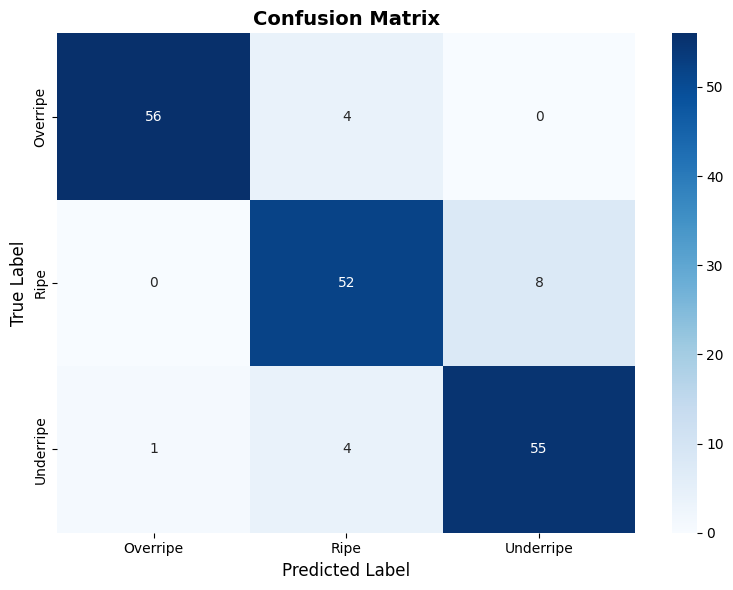

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if cm is None:
    print("Skipping confusion matrix plot: run evaluation first and ensure test_ds_pp is available.")
else:
    # ===== 1. Confusion Matrix Heatmap =====
    fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,          # show counts in each cell
        fmt="d",             # integer format
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax_cm,
    )
    ax_cm.set_xlabel("Predicted Label", fontsize=12)
    ax_cm.set_ylabel("True Label", fontsize=12)
    ax_cm.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
    plt.tight_layout()

    # Save as image
    cm_path = os.path.join(MODEL_DIR, f"confusion_matrix_{TIMESTAMP}.png")
    fig_cm.savefig(cm_path, dpi=150)
    print(f"Confusion matrix saved to {cm_path}")
    plt.show()

Metrics bar chart saved to saved_models\classification_metrics_20260311_190835.png


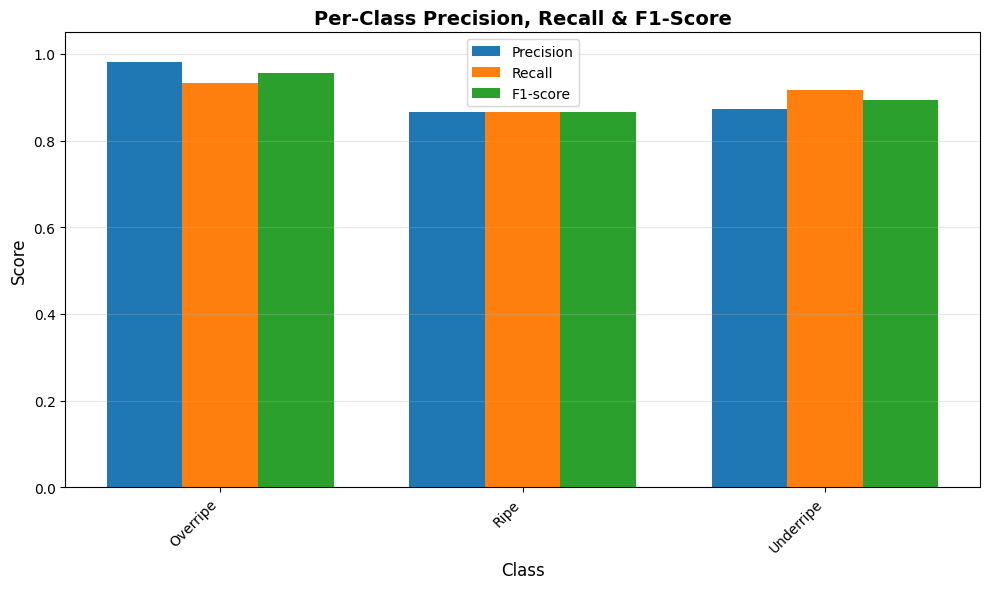

In [ ]:
# ===== 2. Per-Class Precision / Recall / F1-Score Bar Chart =====
import pandas as pd

if not report_dict:
    print("Skipping metrics bar chart: classification report is unavailable.")
else:
    # Extract per-class rows only (skip 'accuracy', 'macro avg', 'weighted avg')
    per_class = {k: v for k, v in report_dict.items() if k in class_names}
    df_report = pd.DataFrame(per_class).T  # rows = classes, columns = precision/recall/f1/support

    # Plot grouped bar chart
    metrics_to_plot = ["precision", "recall", "f1-score"]
    x = np.arange(len(class_names))
    width = 0.25

    fig_bar, ax_bar = plt.subplots(figsize=(10, 6))
    for i, metric in enumerate(metrics_to_plot):
        ax_bar.bar(x + i * width, df_report[metric], width, label=metric.capitalize())

    ax_bar.set_xlabel("Class", fontsize=12)
    ax_bar.set_ylabel("Score", fontsize=12)
    ax_bar.set_title("Per-Class Precision, Recall & F1-Score", fontsize=14, fontweight="bold")
    ax_bar.set_xticks(x + width)
    ax_bar.set_xticklabels(class_names, rotation=45, ha="right")
    ax_bar.set_ylim(0, 1.05)
    ax_bar.legend()
    ax_bar.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    # Save as image
    bar_path = os.path.join(MODEL_DIR, f"classification_metrics_{TIMESTAMP}.png")
    fig_bar.savefig(bar_path, dpi=150)
    print(f"Metrics bar chart saved to {bar_path}")
    plt.show()

In [ ]:
# ===== 3. Export Classification Report & Confusion Matrix to Excel =====
excel_path = ""

if cm is None or not report_dict:
    print("Skipping Excel export: evaluation outputs are unavailable.")
else:
    # Build the full report DataFrame (per-class + summary rows)
    full_report = pd.DataFrame(report_dict).T
    full_report.index.name = "Class"

    # Build confusion matrix DataFrame with class labels
    df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
    df_cm.index.name = "True Label"
    df_cm.columns.name = "Predicted Label"

    # Write both sheets into one Excel workbook
    excel_path = os.path.join(MODEL_DIR, f"classification_report_{TIMESTAMP}.xlsx")
    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        full_report.to_excel(writer, sheet_name="Classification Report")
        df_cm.to_excel(writer, sheet_name="Confusion Matrix")

    print(f"Excel report saved to {excel_path}")
    print("\nClassification Report (preview):")
    display(full_report)
    print("\nConfusion Matrix (preview):")
    display(df_cm)

Excel report saved to saved_models\classification_report_20260311_190835.xlsx

Classification Report (preview):


,precision,recall,f1-score,support
Class,,,,
Overripe,0.982456,0.933333,0.957265,60.000000
Ripe,0.866667,0.866667,0.866667,60.000000
Underripe,0.873016,0.916667,0.894309,60.000000
accuracy,0.905556,0.905556,0.905556,0.905556
macro avg,0.907380,0.905556,0.906080,180.000000
weighted avg,0.907380,0.905556,0.906080,180.000000



Confusion Matrix (preview):


Predicted Label,Overripe,Ripe,Underripe
True Label,,,
Overripe,56,4,0
Ripe,0,52,8
Underripe,1,4,55


## 6b. Experiment Log


Each run appends a row to `saved_models/experiment_log.csv`, recording configuration (mode, epochs, batch size, val split, learning rates, backbone freeze status, dataset sizes) and outcomes (accuracy, macro precision/recall/F1, artifact paths). This enables side-by-side comparison across experiments.

In [ ]:
# ===== Experiment Logger =====
# Appends one row per run to a CSV so you can track how each change affects results.

import csv
import pandas as pd

log_path = os.path.join(MODEL_DIR, "experiment_log.csv")
log_exists = os.path.exists(log_path)

# Determine which mode was used this run
if DO_TRAIN and DO_FINE_TUNE:
    run_mode = "full_train + fine_tune"
elif DO_TRAIN:
    run_mode = "full_train"
elif DO_SMOKE:
    run_mode = "smoke_test"
else:
    run_mode = "no_training"

# Extract key metrics from the report_dict (already computed in evaluation cells)
if isinstance(report_dict, dict):
    accuracy = report_dict.get("accuracy", 0)
    macro_f1 = report_dict.get("macro avg", {}).get("f1-score", 0)
    macro_precision = report_dict.get("macro avg", {}).get("precision", 0)
    macro_recall = report_dict.get("macro avg", {}).get("recall", 0)
else:
    accuracy = 0
    macro_f1 = 0
    macro_precision = 0
    macro_recall = 0

# Get learning rates from the model's optimizer and training history
initial_lr = float(tf.keras.backend.get_value(model.optimizer.learning_rate))
if "history" in locals() and hasattr(history, "history"):
    final_lr = history.history.get("learning_rate", [initial_lr])[-1]
else:
    final_lr = initial_lr

# Determine backbone freeze status safely
backbone_unfrozen = base_model.trainable if (use_transfer and "base_model" in locals()) else "N/A"
best_model_logged = best_model_path if "best_model_path" in locals() else ""
excel_report_logged = excel_path if "excel_path" in locals() else ""

# Build the log row
log_row = {
    "timestamp": TIMESTAMP,
    "run_mode": run_mode,
    "epochs_config": EPOCHS,
    "fine_tune_epochs": FINE_TUNE_EPOCHS if DO_FINE_TUNE else 0,
    "batch_size": BATCH_SIZE,
    "val_split": VAL_SPLIT,
    "initial_learning_rate": initial_lr,
    "final_learning_rate": final_lr,
    "backbone_unfrozen": backbone_unfrozen,
    "train_images": train_total,
    "test_images": test_total,
    "num_classes": num_classes,
    "accuracy": round(accuracy, 4),
    "macro_precision": round(macro_precision, 4),
    "macro_recall": round(macro_recall, 4),
    "macro_f1": round(macro_f1, 4),
    "best_model_file": best_model_logged,
    "excel_report": excel_report_logged,
    "notes": "",  # <-- manually add a note here if you want (e.g., "increased augmentation")
}

# Append to CSV (create header if file doesn't exist yet)
with open(log_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=log_row.keys())
    if not log_exists:
        writer.writeheader()
    writer.writerow(log_row)

print(f"Experiment logged to {log_path}")
print(f"  Run: {run_mode} | Acc: {accuracy:.4f} | F1: {macro_f1:.4f}")
print(f"  Initial LR: {initial_lr} | Final LR: {final_lr} | Batch size: {BATCH_SIZE}")
print(f"  Backbone unfrozen: {backbone_unfrozen}")

# Show the full log so far
log_df = pd.read_csv(log_path)
print(f"\n--- Experiment History ({len(log_df)} runs) ---")
display(log_df)

Experiment logged to saved_models\experiment_log.csv
  Run: full_train + fine_tune | Acc: 0.9056 | F1: 0.9061
  Initial LR: 4.999999873689376e-06 | Final LR: 4.999999873689376e-05 | Batch size: 32
  Backbone unfrozen: True

--- Experiment History (7 runs) ---


,timestamp,run_mode,epochs_config,fine_tune_epochs,batch_size,val_split,initial_learning_rate,final_learning_rate,backbone_unfrozen,train_images,test_images,num_classes,accuracy,macro_precision,macro_recall,macro_f1,best_model_file,excel_report,notes
0,20260310_212417,smoke_test,10,0,32,0.2,0.000100,0.00010,False,1200,180,3,0.5389,0.6303,0.5389,0.4650,saved_models\palm_ripeness_best_20260310_21241...,saved_models\classification_report_20260310_21...,NaN
1,20260311_155111,full_train,10,0,32,0.2,0.000100,0.00010,False,1200,180,3,0.8833,0.8887,0.8833,0.8837,saved_models\palm_ripeness_best_20260311_15511...,saved_models\classification_report_20260311_15...,NaN
2,20260311_160158,full_train + fine_tune,10,5,32,0.2,0.000005,0.00010,True,1200,180,3,0.8556,0.8684,0.8556,0.8529,saved_models\palm_ripeness_best_20260311_16015...,saved_models\classification_report_20260311_16...,NaN
3,20260311_160736,full_train + fine_tune,10,15,32,0.2,0.000005,0.00010,True,1200,180,3,0.8889,0.8926,0.8889,0.8897,saved_models\palm_ripeness_best_20260311_16073...,saved_models\classification_report_20260311_16...,NaN
4,20260311_170850,full_train,30,0,32,0.2,0.000100,0.00010,False,1200,180,3,0.9278,0.9296,0.9278,0.9282,saved_models\palm_ripeness_best_20260311_17085...,saved_models\classification_report_20260311_17...,NaN
5,20260311_190150,full_train + fine_tune,30,5,32,0.2,0.000005,0.00005,True,1200,180,3,0.9167,0.9177,0.9167,0.9170,saved_models\palm_ripeness_best_20260311_19015...,saved_models\classification_report_20260311_19...,NaN
6,20260311_190835,full_train + fine_tune,30,15,32,0.2,0.000005,0.00005,True,1200,180,3,0.9056,0.9074,0.9056,0.9061,saved_models\palm_ripeness_best_20260311_19083...,saved_models\classification_report_20260311_19...,NaN


## 7. Per-File Prediction Helper


Provides `dataset_with_filenames` to build a batched dataset that yields `(image, one_hot_label, filepath)` tuples. Paths are normalised for TensorFlow string ops on Windows, and labels are encoded via a lookup table built from the detected class list—useful for per-file error analysis and custom reporting.

In [22]:
# ---------- Per-file prediction helper ----------
# FIX #7: Normalise path separators so tf.strings.split works on Windows.
# FIX #9: Accept class_names as a parameter — no globals() dependency.

def dataset_with_filenames(root, class_names_list, img_size=IMG_SIZE, batch_size=BATCH_SIZE):
    """
    Build a tf.data.Dataset that yields (image, one-hot label, filepath) tuples.
    Useful for per-file reporting and error analysis.

    Args:
        root:             Root folder with one sub-folder per class.
        class_names_list: Ordered list of class names (must match training order).
        img_size:         Target image dimensions.
        batch_size:       Batch size.

    Returns:
        A batched, prefetched tf.data.Dataset of (image, one_hot_label, filepath).
    """
    pattern = os.path.join(root, "*", "*")
    files = tf.data.Dataset.list_files(pattern, shuffle=False)

    def _process(filepath):
        img = tf.io.read_file(filepath)
        img = tf.image.decode_image(img, channels=3)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, img_size)

        # FIX #7: Normalise backslashes to forward slashes for cross-platform support
        normalised = tf.strings.regex_replace(filepath, r"\\\\", "/")
        parts = tf.strings.split(normalised, "/")
        label = parts[-2]  # parent folder name = class label
        return img, label, filepath

    ds = files.map(_process, num_parallel_calls=AUTOTUNE)

    # Encode string labels to one-hot vectors using a lookup table
    name_to_index = {name: idx for idx, name in enumerate(class_names_list)}
    keys = tf.constant(list(name_to_index.keys()))
    vals = tf.constant(list(name_to_index.values()), dtype=tf.int64)
    table = tf.lookup.StaticHashTable(
        tf.lookup.KeyValueTensorInitializer(keys, vals), default_value=-1
    )

    def _encode(img, label, filepath):
        idx = table.lookup(label)
        one_hot = tf.one_hot(idx, depth=len(class_names_list))
        return img, one_hot, filepath

    ds = ds.map(_encode, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

print("Helper function `dataset_with_filenames(root, class_names_list)` defined.")
print("Example usage: ds = dataset_with_filenames(TEST_ROOT, class_names)")
print("\nAll improvements applied. Pipeline ready.")

Helper function `dataset_with_filenames(root, class_names_list)` defined.
Example usage: ds = dataset_with_filenames(TEST_ROOT, class_names)

All improvements applied. Pipeline ready.


## 8. Pipeline Summary


1. **Configure** paths, hyperparameters, and run modes.


2. **Load & split** the training set into train/validation; keep the test set held out.


3. **Preprocess** images with MobileNetV2 `preprocess_input`; map and prefetch datasets.


4. **Build model** with data augmentation and a frozen MobileNetV2 backbone plus a lightweight head.


5. **Train** with callbacks; optionally fine-tune upper backbone layers at a lower learning rate.


6. **Evaluate** once on the held-out test set to compute metrics and the confusion matrix.


7. **Visualise & export** confusion matrix and per-class metrics; write Excel reports.


8. **Log experiments** to CSV with configs, metrics, and artifact paths for later comparison.


9. **Analyze files** with the helper dataset to inspect per-image predictions when needed.